# Giai đoạn 6: Signal Quality Index (SQI) trên dữ liệu gốc (Raw PPG)
Phương pháp lọc nhiễu tốt nhất trong xử lý tín hiệu y sinh là **lọc ngay trên sóng thô (Raw Signal)** trước khi trích xuất đặc trưng. Ở notebook này, chúng ta sẽ xây dựng một bộ lọc SQI (Signal Quality Index) chặn đứng các đoạn dữ liệu nhiễu do cử động (Motion Artifacts) hoặc mất tín hiệu (Flatline) trước khi AI được học.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks, butter, filtfilt, welch
from scipy.interpolate import interp1d
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import lightgbm as lgb
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

### 1. Hàm trích xuất đặc trưng cơ bản (Time & Frequency Domain)

In [12]:
def butter_bandpass_filter(data, lowcut=0.5, highcut=8.0, fs=125.0, order=3):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def calculate_time_domain(rr_intervals):
    if len(rr_intervals) < 2:
        return {k: np.nan for k in ['Mean_NN', 'SDNN', 'RMSSD', 'pNN50', 'NN50', 'CV']}
    mean_nn = np.mean(rr_intervals)
    sdnn = np.std(rr_intervals, ddof=1)
    diff_nn = np.diff(rr_intervals)
    rmssd = np.sqrt(np.mean(diff_nn**2))
    nn50 = np.sum(np.abs(diff_nn) > 50)
    pnn50 = (nn50 / len(diff_nn)) * 100 if len(diff_nn) > 0 else 0
    cv = (sdnn / mean_nn) * 100 if mean_nn > 0 else np.nan
    return {'Mean_NN': mean_nn, 'SDNN': sdnn, 'RMSSD': rmssd, 'pNN50': pnn50, 'NN50': nn50, 'CV': cv}

def calculate_frequency_domain(rr_intervals, fs_interp=4.0):
    nan_result = {k: np.nan for k in ['LF', 'HF', 'LF_HF_Ratio', 'LF_norm', 'HF_norm', 'Total_Power']}
    if len(rr_intervals) < 10: return nan_result
    
    t = np.cumsum(rr_intervals) / 1000.0
    t -= t[0]
    rr_sec = rr_intervals / 1000.0
    
    try:
        f_interp = interp1d(t, rr_sec, kind='cubic')
        t_interp = np.arange(t[0], t[-1], 1.0 / fs_interp)
        rr_interp = f_interp(t_interp)
    except: return nan_result
        
    nperseg = min(256, len(rr_interp))
    if nperseg < 2: return nan_result
        
    f, pxx = welch(rr_interp, fs=fs_interp, nperseg=nperseg)
    lf_band = (f >= 0.04) & (f <= 0.15)
    hf_band = (f >= 0.15) & (f <= 0.4)
    df = f[1] - f[0]
    lf = np.sum(pxx[lf_band]) * df
    hf = np.sum(pxx[hf_band]) * df
    
    total_power = lf + hf
    lf_hf_ratio = lf / hf if hf > 0 else np.nan
    lf_norm = (lf / total_power) * 100 if total_power > 0 else np.nan
    hf_norm = (hf / total_power) * 100 if total_power > 0 else np.nan
    
    return {'LF': lf, 'HF': hf, 'LF_HF_Ratio': lf_hf_ratio, 'LF_norm': lf_norm, 'HF_norm': hf_norm, 'Total_Power': total_power}

### 2. Xây dựng Bộ lọc Chất lượng tín hiệu (SQI) chuyên sâu

In [13]:
def extract_features_with_sqi(time_array, ppg_array, fs=125.0):
    # --- SQI BƯỚC 1: KIỂM TRA FLATLINE (Mất tín hiệu) ---
    if np.std(ppg_array) < 1e-4:
        return None, "Mất tín hiệu (Flatline)"
        
    clean_ppg = butter_bandpass_filter(ppg_array, fs=fs)
    min_distance = int(0.25 * fs) # Tương đương nhịp tim tối đa 240 BPM
    peaks, _ = find_peaks(clean_ppg, distance=min_distance, prominence=np.std(clean_ppg)*0.5)
    
    # --- SQI BƯỚC 2: KIỂM TRA SỐ LƯỢNG NHỊP TIM ---
    # Trong 30s, nhịp tim bình thường dao động từ 15 nhịp (30 BPM) đến 110 nhịp (220 BPM)
    if len(peaks) < 15:
        return None, "Nhịp quá chậm hoặc mất tín hiệu (Ít hơn 30 BPM)"
    if len(peaks) > 110:
        return None, "Nhiễu rung hoặc nhịp quá nhanh vô lý (Nhiều hơn 220 BPM)"
        
    # --- SQI BƯỚC 3: KIỂM TRA NHIỄU CỬ ĐỘNG (Motion Artifact) ---
    # Nếu chênh lệch biên độ giữa các đỉnh quá lớn (CV của biên độ > 1.5) => Chắc chắn là do cử động
    peak_amps = clean_ppg[peaks]
    if np.std(peak_amps) / (np.mean(peak_amps) + 1e-6) > 1.5:
        return None, "Nhiễu cử động mạnh (Motion Artifact)"
        
    # Tính toán đặc trưng nếu pass qua bài test SQI
    peak_times = time_array[peaks]
    rr_intervals = np.diff(peak_times) * 1000.0
    
    # --- SQI BƯỚC 4: LỌC R-R INTERVALS VÔ LÝ ---
    valid_rr = rr_intervals[(rr_intervals >= 300) & (rr_intervals <= 2000)]
    if len(valid_rr) < 10:
        return None, "Quá ít nhịp R-R hợp lệ"
        
    features = {'HR_mean': 60000.0 / np.mean(valid_rr)}
    features.update(calculate_time_domain(valid_rr))
    features.update(calculate_frequency_domain(valid_rr))
    
    for k, v in features.items():
        if np.isnan(v): features[k] = 0.0
            
    return features, "Thành công"

### 3. Đọc dữ liệu Raw và Trích xuất Feature (Áp dụng SQI)

In [14]:
raw_data_path = '../../data/train/ppg_af_train.csv'
print("Đang đọc dữ liệu sóng thô (Raw PPG). Vui lòng đợi vì file có thể khá lớn...")
df_raw = pd.read_csv(raw_data_path)
print(f"Tổng số điểm tín hiệu: {len(df_raw)}")

FS = 125.0
WINDOW_SIZE_SEC = 30
window_size_samples = int(WINDOW_SIZE_SEC * FS)
total_samples = len(df_raw)

features_list = []
sqi_rejection_stats = {}

print("\nBắt đầu trích xuất đặc trưng có bộ lọc SQI...")
for start_idx in range(0, total_samples, window_size_samples):
    end_idx = start_idx + window_size_samples
    if end_idx > total_samples: break
        
    window = df_raw.iloc[start_idx:end_idx]
    label = 1 if np.mean(window['status'].values) > 0.5 else 0
    
    time_arr = window['time'].values
    ppg_arr = window['ppg'].values
    
    feats, status_msg = extract_features_with_sqi(time_arr, ppg_arr, fs=FS)
    
    if feats is not None:
        feats['status'] = label
        features_list.append(feats)
    else:
        # Thống kê lý do bị loại
        sqi_rejection_stats[status_msg] = sqi_rejection_stats.get(status_msg, 0) + 1

df_clean = pd.DataFrame(features_list)
print(f"\n🎉 Đã trích xuất thành công {len(df_clean)} cửa sổ 30s chất lượng cao.")

print("\n--- THỐNG KÊ LỌC NHIỄU (SQI) ---")
for k, v in sqi_rejection_stats.items():
    print(f"- Bị loại do {k}: {v} cửa sổ")

# Lưu dữ liệu sạch
os.makedirs('../../data/features', exist_ok=True)
df_clean.to_csv('../../data/features/mimic_train_features_sqi_cleaned.csv', index=False)
print("\nĐã lưu tập dữ liệu sạch vào: data/features/mimic_train_features_sqi_cleaned.csv")

Đang đọc dữ liệu sóng thô (Raw PPG). Vui lòng đợi vì file có thể khá lớn...
Tổng số điểm tín hiệu: 4725032

Bắt đầu trích xuất đặc trưng có bộ lọc SQI...

🎉 Đã trích xuất thành công 1200 cửa sổ 30s chất lượng cao.

--- THỐNG KÊ LỌC NHIỄU (SQI) ---
- Bị loại do Nhịp quá chậm hoặc mất tín hiệu (Ít hơn 30 BPM): 58 cửa sổ
- Bị loại do Nhiễu cử động mạnh (Motion Artifact): 2 cửa sổ

Đã lưu tập dữ liệu sạch vào: data/features/mimic_train_features_sqi_cleaned.csv


### 4. Huấn luyện mô hình siêu tốc với LightGBM trên Dữ liệu Sạch từ gốc

Đang Tuning LightGBM trên tập dữ liệu hoàn toàn tinh khiết...

KẾT QUẢ CUỐI CÙNG: DỮ LIỆU SẠCH TỪ RAW SIGNAL
🎯 Accuracy  : 0.9542
🎯 Precision : 0.9291
🎯 Recall    : 0.9833
🎯 F1-Score  : 0.9555


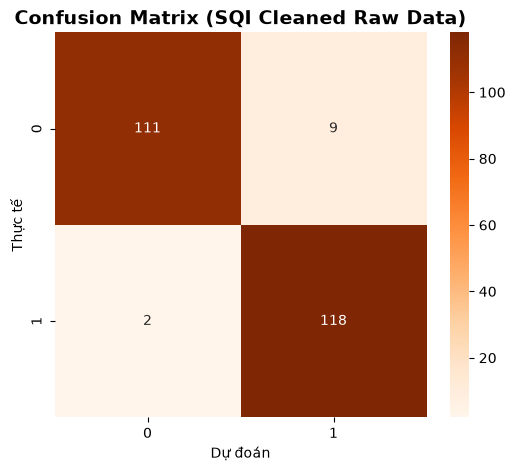


Đã lưu mô hình tại: models/compare/mimic_lightgbm_sqi_raw_clean.pkl


In [15]:
X = df_clean.drop(columns=['status'])
y = df_clean['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

lgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', lgb.LGBMClassifier(random_state=42, verbose=-1))
])

param_grid = {
    'classifier__n_estimators': [300, 500],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__num_leaves': [31, 50]
}

print("Đang Tuning LightGBM trên tập dữ liệu hoàn toàn tinh khiết...")
grid_search = GridSearchCV(estimator=lgb_pipeline, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_lgb = grid_search.best_estimator_
y_pred = best_lgb.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*50)
print("KẾT QUẢ CUỐI CÙNG: DỮ LIỆU SẠCH TỪ RAW SIGNAL")
print("="*50)
print(f"🎯 Accuracy  : {acc:.4f}")
print(f"🎯 Precision : {prec:.4f}")
print(f"🎯 Recall    : {rec:.4f}")
print(f"🎯 F1-Score  : {f1:.4f}")
print("="*50)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix (SQI Cleaned Raw Data)', fontsize=14, fontweight='bold')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

# Lưu mô hình cuối cùng
joblib.dump(best_lgb, '../../models/compare/mimic_lightgbm_sqi_raw_clean.pkl')
print("\nĐã lưu mô hình tại: models/compare/mimic_lightgbm_sqi_raw_clean.pkl")